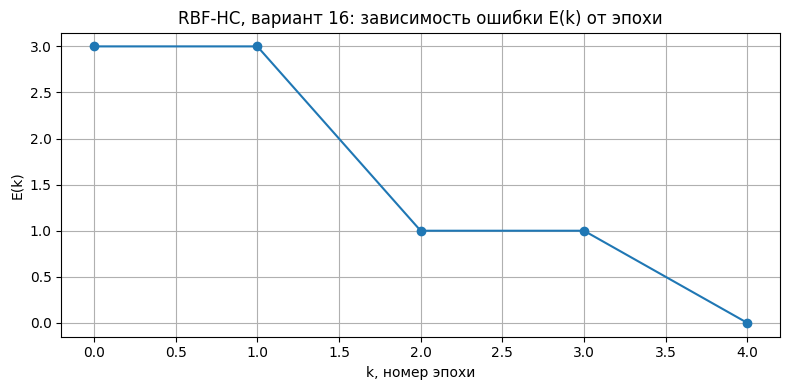

In [4]:
import itertools
import math
import sys
import matplotlib.pyplot as plt

class Tee:
    def __init__(self, *streams):
        self.streams = streams

    def write(self, data):
        for s in self.streams:
            s.write(data)
            s.flush()

    def flush(self):
        for s in self.streams:
            s.flush()

def boolean_function(x1, x2, x3, x4):   
    part1 = x1 or x2 or x3
    part2 = x2 or x3 or x4
    return int(not (part1 and part2))

def generate_dataset():
    dataset = []
    for x1 in (0, 1):
        for x2 in (0, 1):
            for x3 in (0, 1):
                for x4 in (0, 1):
                    x = [float(x1), float(x2), float(x3), float(x4)]
                    t = boolean_function(x1, x2, x3, x4)
                    dataset.append((x, t))
    return dataset

class RBFNetwork:
    def __init__(self, centers, lr=0.05):

        self.centers = centers
        self.J = len(centers)
        self.lr = lr
        self.v = [0.0] * (self.J + 1)

    def phi_j(self, j, x):
        c = self.centers[j]
        dist2 = sum((xi - ci) ** 2 for xi, ci in zip(x, c))
        return math.exp(-dist2)

    def forward(self, x):
        phis = [self.phi_j(j, x) for j in range(self.J)]
        net = self.v[0] + sum(vj * phi for vj, phi in zip(self.v[1:], phis))
        y = 1 if net >= 0 else 0
        return y, net, phis

def count_errors_rbf(network, dataset):
    total_error = 0
    for x, t in dataset:
        y, _, _ = network.forward(x)
        total_error += abs(t - y)
    return total_error


def train_rbf(network, train_set, full_dataset, max_epochs=200):
    epochs = []
    errors = []

    for epoch in range(max_epochs):
        # один проход по обучающей выборке
        for x, t in train_set:
            y, _, phis = network.forward(x)
            delta = t - y  
            if delta != 0:
                network.v[0] += network.lr * delta * 1.0
                for j in range(network.J):
                    network.v[j + 1] += network.lr * delta * phis[j]

        total_error = count_errors_rbf(network, full_dataset)
        epochs.append(epoch)
        errors.append(total_error)
        print(f"Epoch {epoch:3d}: E = {total_error:2d}, v = {network.v}")

        if total_error == 0:
            break

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, errors, marker="o")
    plt.xlabel("k, номер эпохи")
    plt.ylabel("E(k)")
    plt.title("RBF‑НС, вариант 16: зависимость ошибки E(k) от эпохи")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("rbf_errors_variant16.png", dpi=120)
    plt.show()

    return epochs, errors


def train_rbf_silent(network, train_set, full_dataset, max_epochs=200):
    for epoch in range(max_epochs):
        for x, t in train_set:
            y, _, phis = network.forward(x)
            delta = t - y
            if delta != 0:
                network.v[0] += network.lr * delta * 1.0
                for j in range(network.J):
                    network.v[j + 1] += network.lr * delta * phis[j]
        if count_errors_rbf(network, full_dataset) == 0:
            break


def find_min_vyborka_rbf(full_dataset, lr=0.05, max_epochs=200):
    n = len(full_dataset)
    print("\nПоиск минимальной обучающей выборки для RBF‑НС:")

    for k in range(1, n + 1):
        found_indices = None
        tried = 0

        for combo in itertools.combinations(range(n), k):
            subset = [full_dataset[i] for i in combo]
            centers = [x for (x, _) in subset]
            net = RBFNetwork(centers, lr=lr)

            train_rbf_silent(net, subset, full_dataset, max_epochs=max_epochs)
            tried += 1

            if count_errors_rbf(net, full_dataset) == 0:
                found_indices = list(combo)
                break

        total = math.comb(n, k)
        status = "НАЙДЕНА" if found_indices is not None else "не найдена"
        print(f"  k = {k:2d}: проверено {tried:5d}/{total:5d} комбинаций, {status}")

        if found_indices is not None:
            print(f"\nМинимальный размер обучающей выборки: {k}")
            print(f"Индексы (от 0 до {n - 1}): {found_indices}")
            print("Векторы обучающей выборки:")
            for idx in found_indices:
                x, t = full_dataset[idx]
                xi = [int(v) for v in x]
                print(f"  x = {xi},  t = {t}")
            return [full_dataset[i] for i in found_indices], found_indices

    print("Подходящая выборка не найдена (увеличьте max_epochs).")
    return full_dataset, list(range(n))

if __name__ == "__main__":
    log_file = open("results_rbf.txt", "w", encoding="utf-8")
    sys.stdout = Tee(sys.__stdout__, log_file)

    dataset = generate_dataset()

    print("Таблица истинности для варианта 16:")
    print("x1 x2 x3 x4 | F")
    j0 = j1 = 0
    for x, t in dataset:
        xi = [int(v) for v in x]
        print(f"{xi[0]}  {xi[1]}  {xi[2]}  {xi[3]}  | {t}")
        if t == 0:
            j0 += 1
        else:
            j1 += 1

    min_train_set, indices = find_min_vyborka_rbf(
        dataset, lr=0.3, max_epochs=200
    )

    # Обучение сети на найденной минимальной выборке
    centers = [x for (x, _) in min_train_set]
    rbf_net = RBFNetwork(centers, lr=0.05)
    print("\nОбучение RBF‑НС на минимальной выборке:")
    epochs, errors = train_rbf(
        rbf_net, min_train_set, dataset, max_epochs=200
    )

    print("\nИтоговые веса v = [v0, v1, ..., vJ]:")
    print(rbf_net.v)
    print(f"Число эпох обучения: {len(epochs)}")

    log_file.close()
    sys.stdout = sys.__stdout__
    print("\nРезультаты сохранены в results_rbf.txt, график — в rbf_errors_variant16.png")